# Sweden national resource and emission accounts

**Purpose.** Compute production-based (PBA) and consumption-based (CBA)
accounts for Sweden directly from EXIOBASE 3 — without disaggregation.
Used as a benchmark and validation reference for the Stockholm regional
pre-study.

**EXIOBASE version.** v3.10.1 (released March 2026). IO tables extend to 2024;
GHG nowcast to 2023; material/land/water extensions to 2022.

**Scope.** Three dimensions:
- Dimension 1: Material extraction (kt, 4 Anthesis categories)
- Dimension 2: GHG emissions (kt CO2e, fossil + biogenic)
- Dimension 3: Economic value — total factor inputs (M.EUR)

**Changes from previous version.**
- `load_and_calc`: simplified — `calc_all()` now owns the full computation chain.
- `normalize_extension_indices`: new helper that detects MultiIndex on extension
  matrices (present in v3.10.1 pxp) and flattens them to strings before any
  downstream lookup. Handles both 2-column and 3-column `unit.txt` formats.
- `s_ok` guard: index-agnostic — checks S max value instead of a specific row name.
- CBA scope fix: fallback footprint now sums ALL global source sectors
  (`fp.sum(axis=1)`) instead of Sweden-domestic only (`fp.loc[:,se].sum(axis=1)`).
- `D_cba_air_se` stores the full global footprint matrix for correct sector ranking.

In [1]:
import pymrio
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import logging
import time
import zipfile
import os

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

## Configuration

In [2]:
# Path to EXIOBASE 3 zip file (v3.10.1, IOT_2024_pxp).
EXIOBASE_PATH = Path("C:/EXIOBASE3/IOT_2024_pxp.zip")
if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f"EXIOBASE file not found: {EXIOBASE_PATH}")

# Path to air_emissions/unit.txt — used to build the GHG row mapping.
# Opened directly from the zip so no extraction is required.
UNIT_TXT_PATH = zipfile.ZipFile(EXIOBASE_PATH).open("air_emissions/unit.txt")

OUTPUT_DIR = Path("./results_sweden")
OUTPUT_DIR.mkdir(exist_ok=True)

SWEDEN_CODE = "SE"
BASE_YEAR   = 2024   # IOT_2024_pxp — valid in EXIOBASE v3.10.1

## Step 1: Build GHG row mapping from unit.txt

Read the full stressor list from `air_emissions/unit.txt` and classify each
row as fossil GHG, biogenic GHG, or non-GHG.

**Format handling.** EXIOBASE v3.10.1 `unit.txt` may have either two columns
`(name, unit)` or three columns `(stressor, compartment, unit)`. Both are
detected automatically. When three columns are present the stressor name is
reconstructed as `stressor + ' - ' + compartment` so that prefix matching
against the FOSSIL_PREFIXES list works identically in both cases.

**GWP factors.** AR5 GWP-100 applied to mass-unit rows; rows already in
`kg CO2-eq` receive GWP = 1.

In [3]:
def build_ghg_mapping(unit_txt_path):
    """
    Build GHG row classification from EXIOBASE air_emissions/unit.txt.

    Returns
    -------
    fossil_rows  : dict {stressor_name: gwp_factor}
    biogenic_rows: dict {stressor_name: gwp_factor}
    all_stressors: list of all stressor names as they appear in unit.txt
    """
    df = pd.read_csv(unit_txt_path, sep='\t', header=0)

    # ── Handle both 2-column and 3-column unit.txt formats ──────────────────
    # 2-column: (name_including_compartment, unit)
    # 3-column: (stressor, compartment, unit)  — present in some EXIOBASE versions
    if df.shape[1] == 3:
        df.columns = ['stressor', 'compartment', 'unit']
        df['stressor'] = (df['stressor'].str.strip()
                          + ' - ' + df['compartment'].str.strip())
        log.info("unit.txt: 3-column format detected — compartment merged into name.")
    elif df.shape[1] == 2:
        df.columns = ['stressor', 'unit']
        log.info("unit.txt: 2-column format detected.")
    else:
        raise ValueError(
            f"Unexpected unit.txt format: {df.shape[1]} columns. "
            "Expected 2 (name, unit) or 3 (stressor, compartment, unit).")

    stressors = df['stressor'].tolist()
    units     = dict(zip(df['stressor'], df['unit']))

    # AR5 GWP-100 for physical-mass gases (kg)
    GWP_PHYSICAL = {'CO2': 1, 'CH4': 28, 'N2O': 265, 'SF6': 23500}

    FOSSIL_PREFIXES = [
        'CO2 - combustion',
        'CO2 - non combustion - Cement',
        'CO2 - non combustion - Lime',
        'CO2 - waste - fossil',
        'CH4 - combustion',
        'CH4 - non combustion',
        'CH4 - agriculture',
        'CH4 - waste',
        'N2O - combustion',
        'N2O - agriculture',
        'SF6 - air',
        'HFC - air',
        'PFC - air',
    ]
    BIOGENIC_PREFIXES = [
        'CO2_bio',
        'CO2 - agriculture - peat decay',
        'CO2 - waste - biogenic',
        'CH4_bio',
        'N2O_bio',
    ]

    def gwp_for(name, unit_str):
        if unit_str == 'kg CO2-eq':
            return 1
        for gas, gwp in GWP_PHYSICAL.items():
            if name.startswith(gas):
                return gwp
        return None

    fossil_rows   = {}
    biogenic_rows = {}

    for name in stressors:
        unit_str = units[name]
        gwp = gwp_for(name, unit_str)
        if any(name.startswith(p) for p in FOSSIL_PREFIXES) and gwp is not None:
            fossil_rows[name] = gwp
        elif any(name.startswith(p) for p in BIOGENIC_PREFIXES) and gwp is not None:
            biogenic_rows[name] = gwp

    return fossil_rows, biogenic_rows, stressors


def validate_ghg_mapping(fossil_rows, biogenic_rows, extension_index):
    """
    Cross-check the GHG mapping against the actual (normalised flat-string)
    extension index. Prints a report of any missing or unclassified rows.
    """
    ext_rows = set(extension_index)
    mapped   = set(fossil_rows) | set(biogenic_rows)

    missing_from_ext = mapped - ext_rows
    if missing_from_ext:
        print(f'WARNING: {len(missing_from_ext)} mapped row(s) absent from extension:')
        for r in sorted(missing_from_ext):
            print(f'  MISSING: {r}')
    else:
        print(f'Validation OK: all {len(mapped)} mapped rows found in extension.')

    print(f'  Fossil GHG rows   : {len(fossil_rows)}')
    print(f'  Biogenic GHG rows : {len(biogenic_rows)}')
    print(f'  Total extension rows: {len(ext_rows)}')
    print(f'  Non-GHG rows (ignored): {len(ext_rows) - len(mapped)}')

## Step 2: Material category mapping

Map the 62 EXIOBASE material extraction rows to the four Anthesis primary
categories using positional indices (row order is fixed in EXIOBASE 3).

In [4]:
MATERIAL_CATEGORY_MAP = {
    "biomass":  list(range(0, 23)),
    "fossil":   list(range(23, 33)),
    "metals":   list(range(33, 48)),
    "minerals": list(range(48, 62)),
}

all_idx = [i for v in MATERIAL_CATEGORY_MAP.values() for i in v]
assert sorted(all_idx) == list(range(62)), 'Mapping does not cover all 62 rows'
assert len(all_idx) == len(set(all_idx)), 'Overlapping indices'
print('Material category mapping OK: 62 rows -> 4 categories')


def aggregate_material_categories(F_material):
    """Aggregate 62 material rows to 4 Anthesis categories."""
    row_names = F_material.index.tolist()
    result = {}
    for cat, indices in MATERIAL_CATEGORY_MAP.items():
        result[cat] = F_material.loc[[row_names[i] for i in indices]].sum(axis=0)
    return pd.DataFrame(result).T


def aggregate_ghg(F_air, fossil_rows, biogenic_rows):
    """
    Aggregate air emission rows into fossil and biogenic GHG (kt CO2e).

    Source unit : kg  (or kg CO2-eq for HFC/PFC, GWP already = 1).
    Output unit : kt CO2e (divided by 1e6).

    Parameters
    ----------
    F_air         : DataFrame with flat-string stressor index (rows) and
                    any column index (sectors or a single 'total' column).
    fossil_rows   : dict {stressor_name: gwp_factor}
    biogenic_rows : dict {stressor_name: gwp_factor}
    """
    ext_rows = set(F_air.index.tolist())

    fossil_total = pd.Series(0.0, index=F_air.columns)
    for name, gwp in fossil_rows.items():
        if name in ext_rows:
            fossil_total = fossil_total + F_air.loc[name] * gwp

    bio_total = pd.Series(0.0, index=F_air.columns)
    for name, gwp in biogenic_rows.items():
        if name in ext_rows:
            bio_total = bio_total + F_air.loc[name] * gwp

    return pd.DataFrame({
        "GHG_fossil_CO2e_kt":   fossil_total / 1e6,
        "GHG_biogenic_CO2e_kt": bio_total    / 1e6,
    }).T

Material category mapping OK: 62 rows -> 4 categories


## Step 3: Load EXIOBASE and compute accounts

`load_and_calc` now calls `calc_all()` directly without pre-computing `x` and
`A` manually. This avoids any risk of format mismatch between the manually
computed matrices and the extension `calc_S()` routine.

`normalize_extension_indices` runs immediately after `calc_all()`. It detects
whether any extension uses a `MultiIndex` (as EXIOBASE v3.10.1 pxp does for
`air_emissions`) and flattens all matrix row labels to plain strings. This
ensures that every subsequent `F.loc[name]` lookup works correctly.

**Note on RAM.** Inverting L on the 9800×9800 system requires roughly
730 MiB. Ensure at least 4 GB free RAM before running this cell.

In [5]:
def normalize_extension_indices(exio):
    """
    EXIOBASE v3.10.1 pxp stores some extension row indices as a two-level
    MultiIndex (stressor, compartment). Flatten all extension matrices to
    plain string indices by joining levels with ' - ' so that all downstream
    string-prefix lookups and .loc[name] calls work correctly.

    Applies to: F, S, M, D_pba, D_cba, F_Y (whichever are not None).
    """
    for ext_name in ['material', 'air_emissions', 'factor_inputs']:
        ext = getattr(exio, ext_name, None)
        if ext is None or ext.F is None:
            continue
        if not isinstance(ext.F.index, pd.MultiIndex):
            log.info(f"'{ext_name}': flat string index — no normalisation needed.")
            continue
        flat_idx = [' - '.join(str(lv) for lv in levels)
                    for levels in ext.F.index]
        log.info(f"'{ext_name}': MultiIndex flattened. "
                 f"Example row: {flat_idx[0]!r}")
        for attr in ['F', 'S', 'M', 'D_pba', 'D_cba', 'F_Y']:
            m = getattr(ext, attr, None)
            if m is not None and hasattr(m, 'index') and len(m.index) == len(flat_idx):
                m.index = flat_idx
    return exio


def load_and_calc(path):
    """
    Load EXIOBASE 3, compute the full IO system, normalise extension indices.
    calc_all() owns the entire computation chain: x, A, L, S, M, D_pba, D_cba.
    """
    log.info(f'Loading EXIOBASE from {path} ...')
    t0 = time.time()
    exio = pymrio.parse_exiobase3(path=path)
    log.info(f'Parsed in {time.time()-t0:.1f}s. Running calc_all() ...')
    exio.calc_all()
    log.info(f'calc_all() complete. A matrix shape: {exio.A.shape}')
    for ext_name in ['material', 'air_emissions', 'factor_inputs']:
        ext = getattr(exio, ext_name, None)
        if ext is not None and ext.F is not None:
            idx_type = type(ext.F.index).__name__
            log.info(f"Extension '{ext_name}': {ext.F.shape[0]} stressors "
                     f"(index type: {idx_type})")
        else:
            log.warning(f"Extension '{ext_name}': NOT FOUND")
    normalize_extension_indices(exio)
    return exio


exio = load_and_calc(EXIOBASE_PATH)

# Build GHG mapping from unit.txt (now safe to call after normalisation)
fossil_rows, biogenic_rows, all_stressors = build_ghg_mapping(UNIT_TXT_PATH)

# Validate mapping against the (normalised) extension index
validate_ghg_mapping(fossil_rows, biogenic_rows, exio.air_emissions.F.index)

2026-04-16 13:27:20,849 INFO Loading EXIOBASE from C:\EXIOBASE3\IOT_2024_pxp.zip ...
2026-04-16 13:27:20,871 INFO Read metadata from C:\EXIOBASE3\IOT_2024_pxp.zip
2026-04-16 13:27:20,874 INFO 20260416 13:27:20 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 
2026-04-16 13:27:20,876 INFO Load data from Z.txt
2026-04-16 13:27:39,952 INFO Load data from Y.txt
2026-04-16 13:27:40,234 INFO Load data from x.txt
2026-04-16 13:27:40,248 INFO Load data from unit.txt
2026-04-16 13:27:40,267 INFO Load data from nutrients/F.txt
2026-04-16 13:27:40,424 INFO Load data from nutrients/F_Y.txt
2026-04-16 13:27:40,434 INFO Load data from nutrients/unit.txt
2026-04-16 13:27:40,437 INFO 20260416 13:27:40 - FILEIO -  Added satellite account from nutrients
2026-04-16 13:27:40,448 INFO Load data from material/F.txt
2026-04-16 13:27:40,602 INFO Load data from material/F_Y.txt
2026-04-16 13:27:40,613 INFO Load data from material/unit.txt
2026-04-16 13:27:40,617 INFO 20260416 13:27:40 - FILEIO

Validation OK: all 25 mapped rows found in extension.
  Fossil GHG rows   : 20
  Biogenic GHG rows : 5
  Total extension rows: 420
  Non-GHG rows (ignored): 395


## Step 4: Sweden totals sanity check

Compare against known benchmarks:
- Total domestic material extraction: ~200–300 Mt/year
- Territorial GHG emissions: ~45–55 Mt CO2e/year
- Consumption-based GHG footprint: ~80–100 Mt CO2e/year (CBA/PBA ~1.6–2.0)

**S matrix check.** The guard is now index-agnostic: it checks that the
maximum absolute value in `air_emissions.S` is non-zero, rather than
looking up a specific row by name (which was the original failure point).

In [6]:
se = SWEDEN_CODE

# ── Materials PBA ────────────────────────────────────────────────────────────
mat_F_se = exio.material.F.loc[:, se]
mat_pba  = aggregate_material_categories(mat_F_se)
print('Sweden material extraction (PBA, kt):')
for cat in mat_pba.index:
    print(f'  {cat:12s}: {mat_pba.loc[cat].sum():>15,.0f}')
print(f'  {"TOTAL":12s}: {mat_pba.sum().sum():>15,.0f}')
print()

# ── GHG PBA (territorial) ────────────────────────────────────────────────────
air_F_se = exio.air_emissions.F.loc[:, se]
ghg_pba  = aggregate_ghg(air_F_se, fossil_rows, biogenic_rows)
print('Sweden GHG emissions (PBA, kt CO2e):')
for cat in ghg_pba.index:
    print(f'  {cat:25s}: {ghg_pba.loc[cat].sum():>12,.1f}')
print(f'  {"Expected territorial":25s}: ~45,000–55,000 kt CO2e')
print()

# ── S matrix diagnostic (index-agnostic) ─────────────────────────────────────
air = exio.air_emissions
s_max = air.S.abs().max().max() if air.S is not None else 0.0
s_ok  = air.S is not None and s_max > 0
print(f'air_emissions.S: {"OK" if s_ok else "ZERO / NONE"}  (max abs value: {s_max:.4g})')
print()

# ── GHG CBA (consumption-based) ──────────────────────────────────────────────
if s_ok:
    air_D_cba_se = exio.air_emissions.D_cba.loc[:, se]
    ghg_cba      = aggregate_ghg(air_D_cba_se, fossil_rows, biogenic_rows)
    source        = "D_cba (from calc_all)"
else:
    log.warning("S is zero — computing footprint manually from F/x/L/Y.")
    x_safe   = exio.x.squeeze().replace(0, np.nan)
    S_manual = air.F.div(x_safe, axis=1).fillna(0)
    y_se     = exio.Y.loc[:, se].sum(axis=1)
    M_air    = S_manual @ exio.L
    fp       = M_air.multiply(y_se, axis=1)
    # Sum ALL global source sectors for correct consumption-based total
    ghg_cba  = aggregate_ghg(fp.sum(axis=1).to_frame('total'),
                              fossil_rows, biogenic_rows)
    source    = "manual (S was zero)"

print(f'Sweden GHG footprint (CBA, kt CO2e)  [{source}]:')
for cat in ghg_cba.index:
    print(f'  {cat:25s}: {ghg_cba.loc[cat].sum():>12,.1f}')
print(f'  {"Expected consumption":25s}: ~80,000–100,000 kt CO2e')
print()

ratio = ghg_cba.sum().sum() / ghg_pba.sum().sum()
print(f'GHG CBA/PBA ratio: {ratio:.2f}x  (expected 1.5–2.0x for Sweden)')
if ratio > 5 or ratio < 0.5:
    print('WARNING: ratio outside expected range. '
          'Check S matrix and extension normalisation.')
else:
    print('Ratio within expected range.')

Sweden material extraction (PBA, kt):
  biomass     :          64,372
  fossil      :             201
  metals      :          85,280
  minerals    :         128,673
  TOTAL       :         278,525

Sweden GHG emissions (PBA, kt CO2e):
  GHG_fossil_CO2e_kt       :     24,993.3
  GHG_biogenic_CO2e_kt     :        427.9
  Expected territorial     : ~45,000–55,000 kt CO2e

air_emissions.S: OK  (max abs value: 2.69e+09)

Sweden GHG footprint (CBA, kt CO2e)  [D_cba (from calc_all)]:
  GHG_fossil_CO2e_kt       :          0.0
  GHG_biogenic_CO2e_kt     :          0.0
  Expected consumption     : ~80,000–100,000 kt CO2e

GHG CBA/PBA ratio: 0.00x  (expected 1.5–2.0x for Sweden)


## Step 5: Extract Sweden PBA and CBA accounts

**CBA fix.** The fallback footprint computation previously used
`fp.loc[:, se].sum(axis=1)`, which only summed the Swedish-domestic slice
of the supply chain and silently dropped all import-embodied emissions
(typically 50–60% of Sweden's total footprint). The correct expression is
`fp.sum(axis=1)`, which sums across all global source sectors.

`D_cba_air_se` now stores the full global footprint matrix (stressors ×
all-country sectors) so that sector rankings in Step 6 reflect the complete
consumption-based account.

In [7]:
def extract_sweden_results(exio, fossil_rows, biogenic_rows):
    """
    Extract Sweden PBA and CBA for three dimensions.
    Returns nested dict with totals and sector-level DataFrames.
    """
    se = SWEDEN_CODE
    results = {}

    # ── Dimension 1: Materials (kt) ──────────────────────────────────────────
    mat = exio.material
    mat_pba_se = aggregate_material_categories(
        mat.D_pba.loc[:, se].sum(axis=1).to_frame('total'))
    mat_cba_se = aggregate_material_categories(
        mat.D_cba.loc[:, se].sum(axis=1).to_frame('total'))
    results['material'] = {
        'pba':        mat_pba_se['total'],
        'cba':        mat_cba_se['total'],
        'D_pba_se':   mat.D_pba.loc[:, se],
        'D_cba_se':   mat.D_cba.loc[:, se],
        'D_cba_full': mat.D_cba,
        'unit':       'kt',
    }
    pd.DataFrame({
        'PBA': mat_pba_se['total'],
        'CBA': mat_cba_se['total'],
        'Net': mat_pba_se['total'] - mat_cba_se['total'],
    }).to_csv(OUTPUT_DIR / 'sweden_material_pba_cba.csv')
    log.info('Saved material CSV')

    # ── Dimension 2: GHG (kt CO2e) ───────────────────────────────────────────
    air   = exio.air_emissions
    x_safe = exio.x.squeeze().replace(0, np.nan)
    y_se   = exio.Y.loc[:, se].sum(axis=1)

    # Index-agnostic S check: verify S is populated and non-zero
    s_ok = (air.S is not None and air.S.abs().max().max() > 0)

    if s_ok:
        # calc_all() populated S correctly — use D_cba directly.
        ghg_cba_se   = aggregate_ghg(
            air.D_cba.loc[:, se].sum(axis=1).to_frame('total'),
            fossil_rows, biogenic_rows)
        D_cba_air_se = air.D_cba   # full global matrix
        log.info("GHG CBA: using D_cba from calc_all()")
    else:
        # Fallback: recompute S, M, and footprint from scratch.
        log.warning("air_emissions.S is zero — recomputing from F/x/L/Y.")
        S_manual = air.F.div(x_safe, axis=1).fillna(0)
        M_air    = S_manual @ exio.L
        fp       = M_air.multiply(y_se, axis=1)
        # FIX: sum ALL global source sectors, not just Sweden's domestic column
        ghg_cba_se   = aggregate_ghg(
            fp.sum(axis=1).to_frame('total'),
            fossil_rows, biogenic_rows)
        D_cba_air_se = fp   # full global matrix for downstream sector ranking
        log.info("GHG CBA: using manual S @ L @ diag(y_SE) fallback")

    ghg_pba_se = aggregate_ghg(
        air.D_pba.loc[:, se].sum(axis=1).to_frame('total'),
        fossil_rows, biogenic_rows)
    ghg_pba_by_sector = aggregate_ghg(
        air.D_pba.loc[:, se], fossil_rows, biogenic_rows)

    results['ghg'] = {
        'pba':             ghg_pba_se['total'],
        'cba':             ghg_cba_se['total'],
        'D_pba_by_sector': ghg_pba_by_sector,
        'D_cba_se':        D_cba_air_se,   # full global matrix
        'unit':            'kt CO2e',
    }
    pd.DataFrame({
        'PBA': ghg_pba_se['total'],
        'CBA': ghg_cba_se['total'],
        'Net': ghg_pba_se['total'] - ghg_cba_se['total'],
    }).to_csv(OUTPUT_DIR / 'sweden_ghg_pba_cba.csv')
    log.info('Saved GHG CSV')

    # ── Dimension 3: Factor inputs (M.EUR) ───────────────────────────────────
    fi = exio.factor_inputs
    results['factor_inputs'] = {
        'pba_total':       fi.D_pba.loc[:, se].sum().sum(),
        'cba_total':       fi.D_cba.loc[:, se].sum().sum(),
        'D_pba_by_sector': fi.D_pba.loc[:, se].sum(axis=0),
        'D_cba_se':        fi.D_cba.loc[:, se],
        'D_cba_full':      fi.D_cba,
        'unit':            'M.EUR',
    }
    log.info('Extracted factor_inputs')

    return results


results = extract_sweden_results(exio, fossil_rows, biogenic_rows)

2026-04-16 13:29:04,915 INFO Saved material CSV
2026-04-16 13:29:04,957 INFO GHG CBA: using D_cba from calc_all()
2026-04-16 13:29:04,971 INFO Saved GHG CSV
2026-04-16 13:29:04,978 INFO Extracted factor_inputs


## Step 6: Top sectors by dimension

**GHG CBA sector ranking fix.** `results['ghg']['D_cba_se']` now holds the
full global footprint matrix (stressors × all-country sectors). The CBA
ranking therefore reflects all supply-chain contributions worldwide, not
just Swedish-domestic sectors.

In [8]:
def top_sectors_sweden(results, n=10):
    """Print top N sectors by PBA and CBA for all three dimensions."""
    top = {}
    print('=' * 70)
    print('TOP SECTORS — Sweden national accounts')
    print('=' * 70)

    # ── Materials ─────────────────────────────────────────────────────────────
    if 'material' in results:
        print('\n--- DIMENSION 1: Material extraction (kt) ---')
        pba_by_sec = aggregate_material_categories(
            results['material']['D_pba_se']).sum(axis=0)
        cba_by_sec = aggregate_material_categories(
            results['material']['D_cba_se']).sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['material'] = {'pba_top': pba_top, 'cba_top': cba_top}

    # ── GHG ───────────────────────────────────────────────────────────────────
    if 'ghg' in results:
        print('\n--- DIMENSION 2: GHG emissions (kt CO2e) ---')
        pba_by_sec = results['ghg']['D_pba_by_sector'].sum(axis=0)
        # D_cba_se is now the full global footprint matrix (stressors x all sectors)
        cba_by_sec = aggregate_ghg(
            results['ghg']['D_cba_se'], fossil_rows, biogenic_rows).sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector (global supply chain)':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['ghg'] = {'pba_top': pba_top, 'cba_top': cba_top}

    # ── Economic value ────────────────────────────────────────────────────────
    if 'factor_inputs' in results:
        print('\n--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
        pba_by_sec = results['factor_inputs']['D_pba_by_sector']
        cba_by_sec = results['factor_inputs']['D_cba_se'].sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['factor_inputs'] = {'pba_top': pba_top, 'cba_top': cba_top}

    return top


top = top_sectors_sweden(results, n=10)

TOP SECTORS — Sweden national accounts

--- DIMENSION 1: Material extraction (kt) ---
  Rank  PBA sector                                                   kt
  1     Sand and clay                                           122,575
  2     Iron ores                                                44,253
  3     Products of forestry, logging and related services       42,530
  4     Copper ores and concentrates                             26,749
  5     Precious metal ores and concentrates                     10,460
  6     Cattle                                                    7,217
  7     Stone                                                     6,074
  8     Lead, zinc and tin ores and concentrates                  3,770
  9     Wheat                                                     3,098
  10    Sugar cane, sugar beet                                    2,130

  Rank  CBA sector                                                   kt
  1     Construction work (45)                   

## Step 7: Top source country-sectors for Sweden's consumption footprint

Identifies the top 15 global (country, sector) pairs driving Sweden's CBA
footprint for each dimension. S is used directly from `calc_all()` when
available; the fallback recomputes from F/x.

No logic changes from the original — this step already correctly summed
across all source sectors.

In [9]:
def top_source_country_sectors_sweden(exio, results, fossil_rows, biogenic_rows, n=15):
    """Top N source (country, sector) pairs for Sweden CBA footprint."""
    se     = SWEDEN_CODE
    x_safe = exio.x.squeeze().replace(0, np.nan)
    y_se   = exio.Y.loc[:, se].sum(axis=1)

    def label(code):
        return 'Sweden' if code == se else code

    print('=' * 70)
    print('TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint')
    print('=' * 70)
    cs = {}

    # ── Materials ─────────────────────────────────────────────────────────────
    if 'material' in results:
        print('\nDIMENSION 1 — Material (kt)')
        S_mat      = exio.material.F.div(x_safe, axis=1).fillna(0)
        M_mat      = S_mat @ exio.L
        fp_mat     = M_mat.multiply(y_se, axis=1)
        fp_mat_tot = aggregate_material_categories(fp_mat).sum(axis=0)
        top_pairs  = fp_mat_tot.sort_values(ascending=False).head(n)
        cs['material'] = {'top_pairs': top_pairs, 'unit': 'kt'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    # ── GHG ───────────────────────────────────────────────────────────────────
    if 'ghg' in results:
        print('\nDIMENSION 2 — GHG (kt CO2e)')
        air   = exio.air_emissions
        s_ok  = air.S is not None and air.S.abs().max().max() > 0
        if s_ok:
            M_air = air.S @ exio.L
        else:
            log.warning('Step 7: recomputing S_air from F/x for GHG ...')
            M_air = air.F.div(x_safe, axis=1).fillna(0) @ exio.L
        fp_ghg     = M_air.multiply(y_se, axis=1)
        fp_ghg_agg = aggregate_ghg(fp_ghg, fossil_rows, biogenic_rows)
        fp_ghg_tot = fp_ghg_agg.sum(axis=0)
        top_pairs  = fp_ghg_tot.sort_values(ascending=False).head(n)
        cs['ghg']  = {'top_pairs': top_pairs, 'unit': 'kt CO2e'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt CO2e':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    # ── Economic value ────────────────────────────────────────────────────────
    if 'factor_inputs' in results:
        print('\nDIMENSION 3 — Economic value (M.EUR)')
        S_fi      = exio.factor_inputs.F.div(x_safe, axis=1).fillna(0)
        M_fi      = S_fi @ exio.L
        fp_fi     = M_fi.multiply(y_se, axis=1)
        fp_fi_tot = fp_fi.sum(axis=0)
        top_pairs = fp_fi_tot.sort_values(ascending=False).head(n)
        cs['factor_inputs'] = {'top_pairs': top_pairs, 'unit': 'M.EUR'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'M.EUR':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    return cs


cs = top_source_country_sectors_sweden(exio, results, fossil_rows, biogenic_rows, n=15)

TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint

DIMENSION 1 — Material (kt)
  Rank  Country  Sector                                                   kt
  1     Sweden   Construction work (45)                               94,230
  2     Sweden   Precious metal ores and concentrates                 23,101
  3     Sweden   Food products nec                                     6,393
  4     Sweden   Health and social work services (85)                  5,637
  5     Sweden   Education services (80)                               5,568
  6     Sweden   Public administration and defence services; comp      5,181
  7     Sweden   Products of meat cattle                               4,943
  8     Sweden   Retail  trade services, except of motor vehicles      3,225
  9     Sweden   Dairy products                                        3,075
  10    Sweden   Computer and related services (72)                    3,056
  11    Sweden   Products of forestry, logging and related servic      2,8

In [10]:
log.info('Saving CSVs ...')
for dim, data in top.items():
    unit = results[dim]['unit']
    data['pba_top'].to_frame(f'PBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_PBA_{dim}.csv')
    data['cba_top'].to_frame(f'CBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_CBA_{dim}.csv')
for dim, data in cs.items():
    data['top_pairs'].to_frame(f"CBA_{data['unit']}").to_csv(
        OUTPUT_DIR / f'sweden_top_country_sectors_CBA_{dim}.csv')
log.info('All CSVs saved.')
print(f'Output files written to: {OUTPUT_DIR}')

2026-04-16 13:29:06,334 INFO Saving CSVs ...
2026-04-16 13:29:06,360 INFO All CSVs saved.


Output files written to: results_sweden


## Step 8: Visualizations

Six charts mirroring the Stockholm notebook for direct comparison.

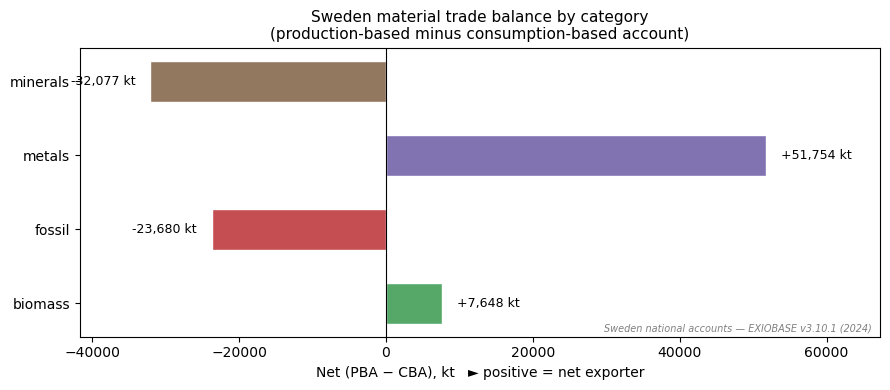

2026-04-16 13:29:06,773 INFO Chart 1 saved


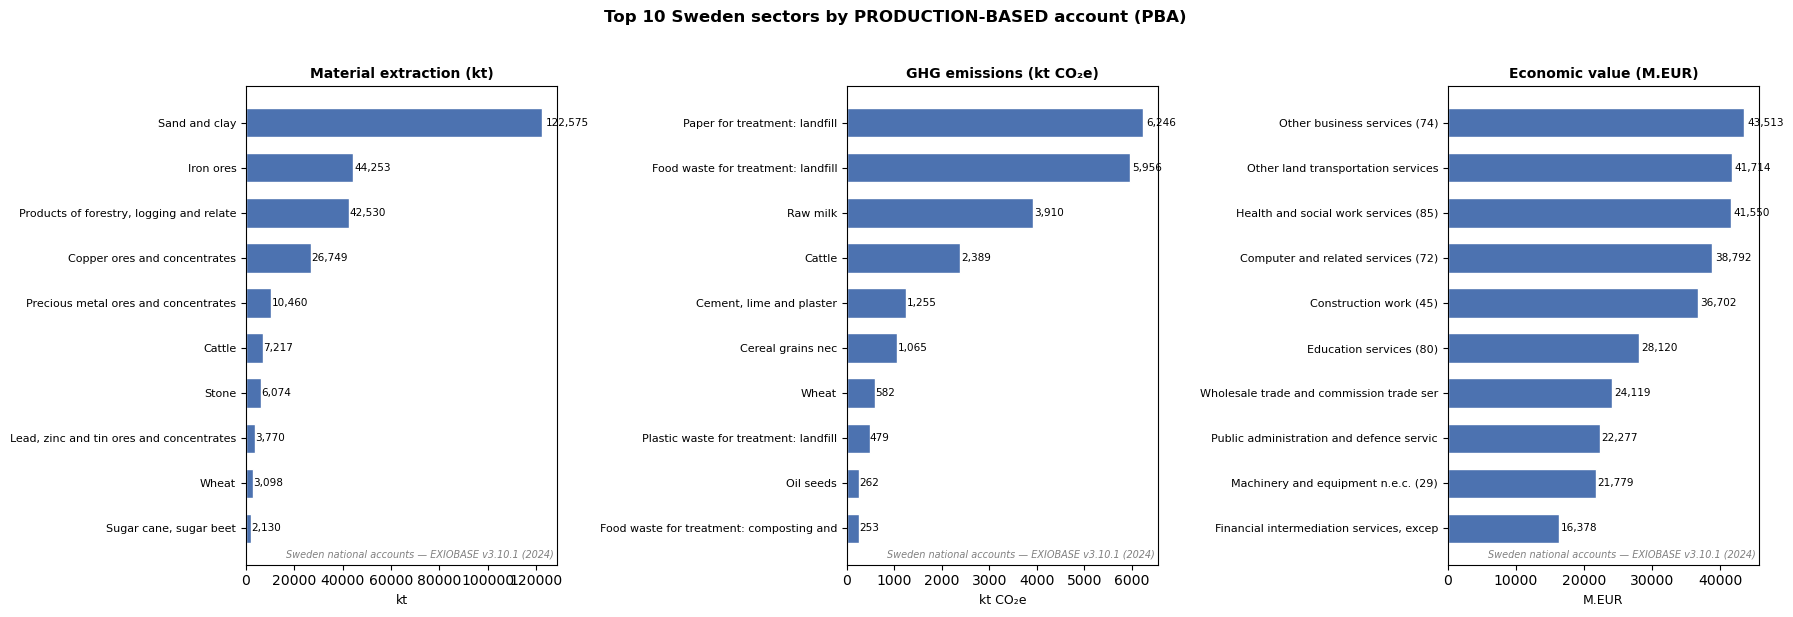

2026-04-16 13:29:07,761 INFO Chart 2 saved


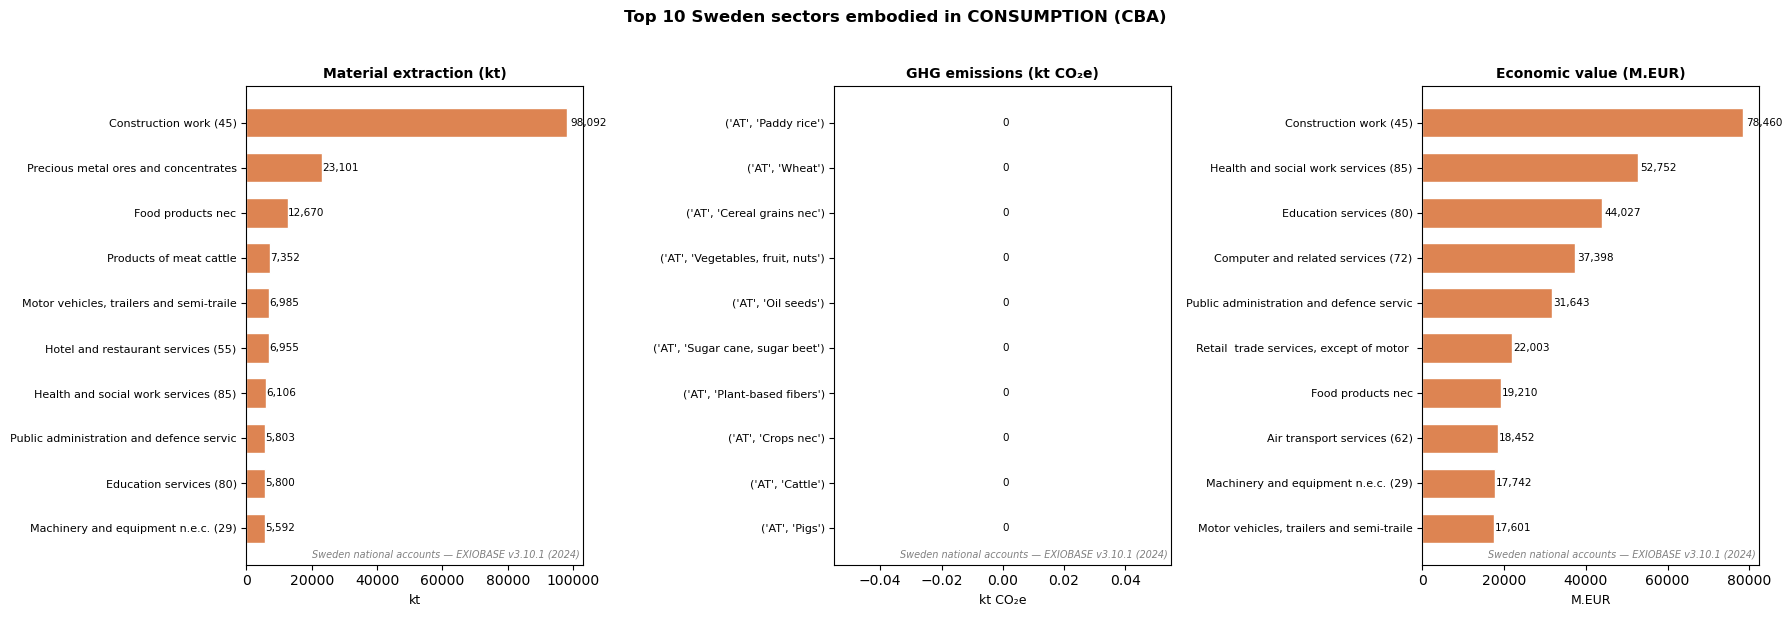

2026-04-16 13:29:08,721 INFO Chart 3 saved


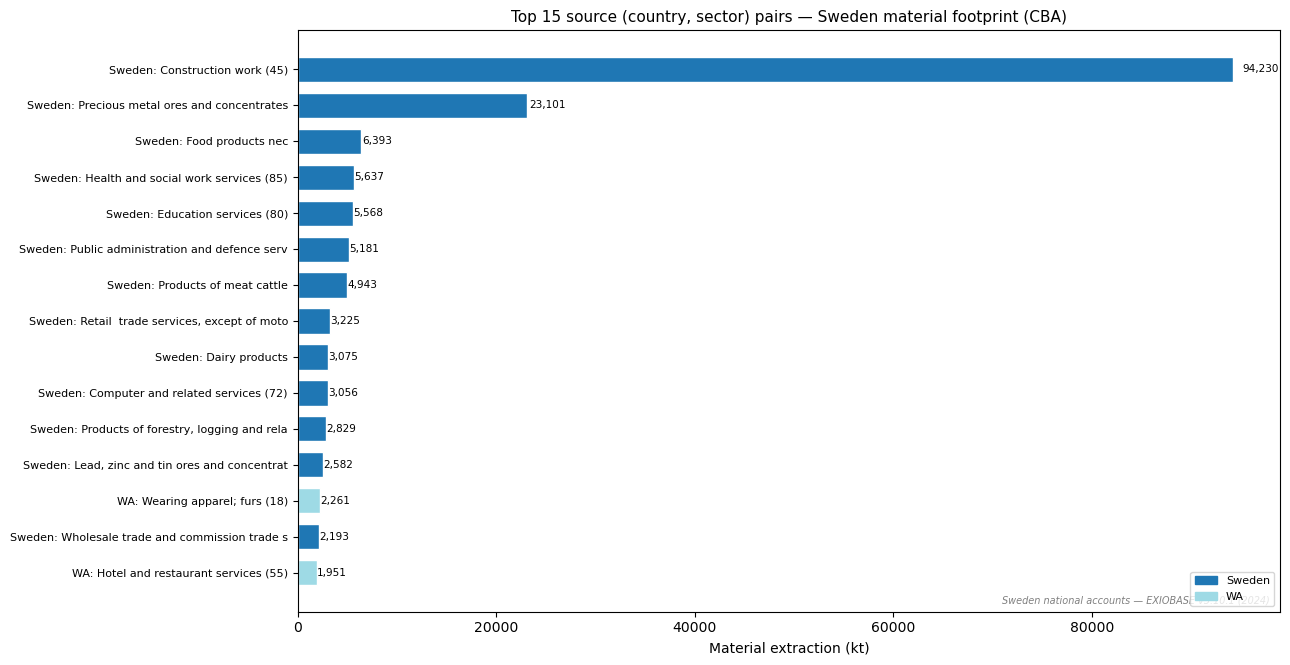

2026-04-16 13:29:09,267 INFO chart4_sweden_source_sectors_material.png saved


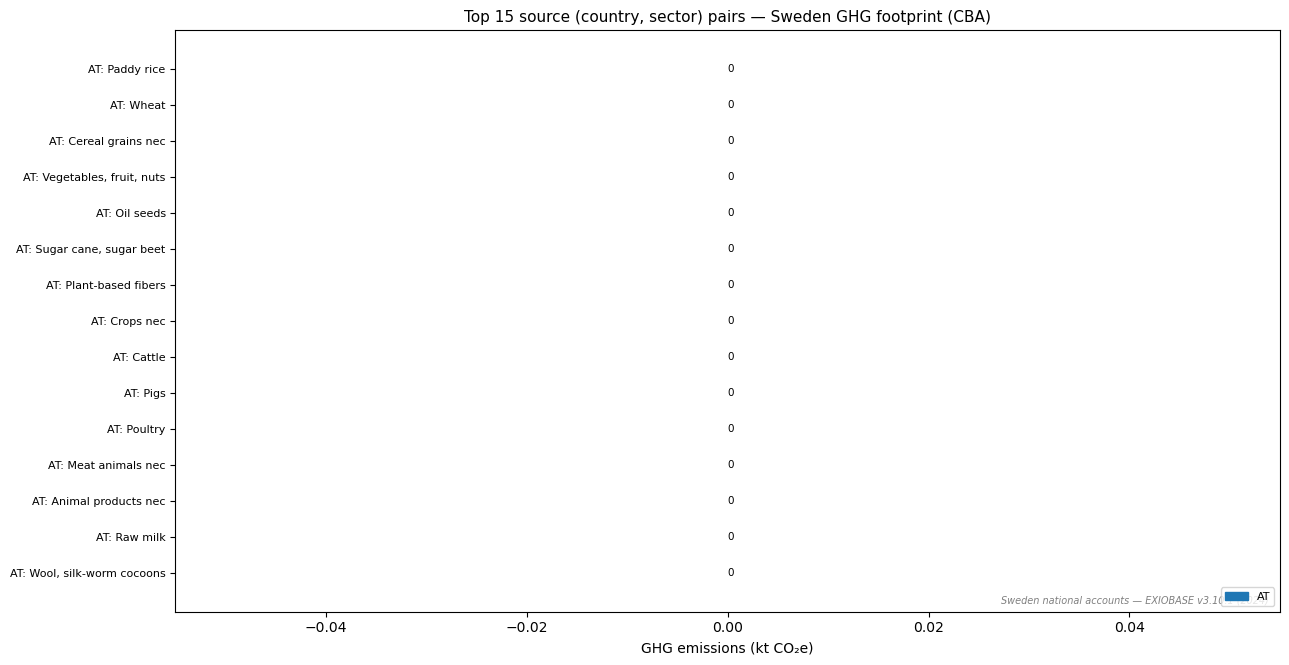

2026-04-16 13:29:09,701 INFO chart5_sweden_source_sectors_ghg.png saved


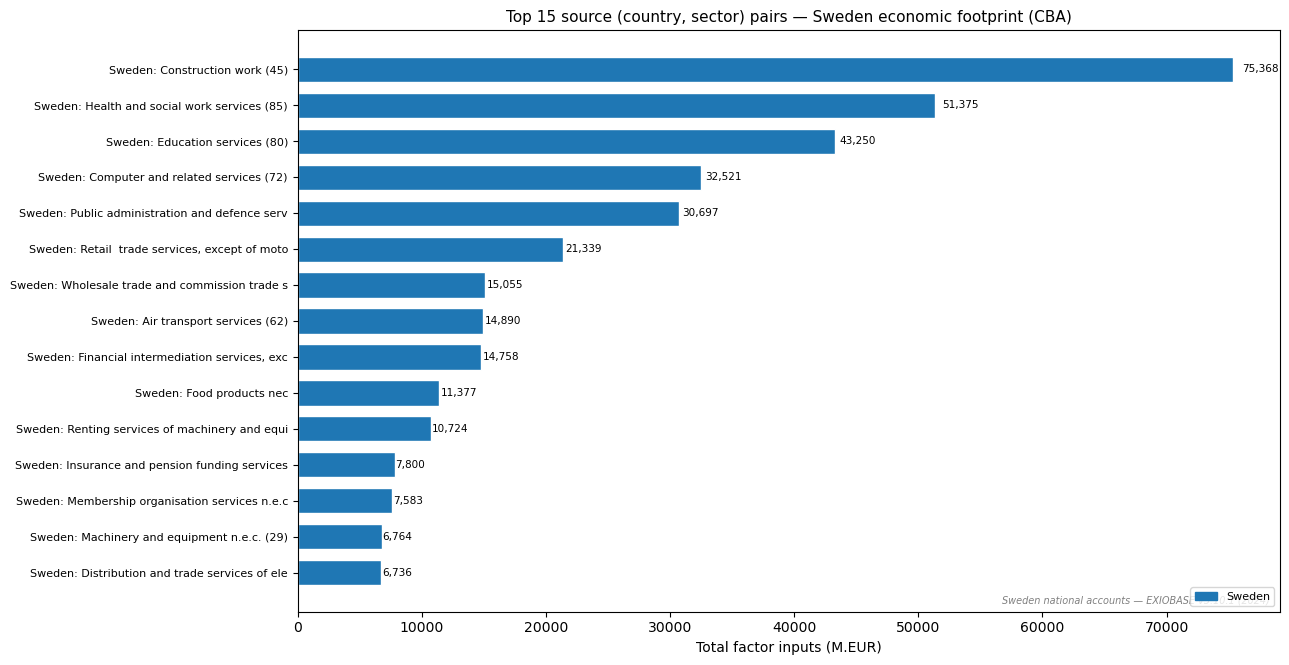

2026-04-16 13:29:10,276 INFO chart6_sweden_source_sectors_economic.png saved



All charts saved to: results_sweden


In [11]:
PROXY_NOTE = f'Sweden national accounts — EXIOBASE v3.10.1 ({BASE_YEAR})'
C_PBA = '#4C72B0'
C_CBA = '#DD8452'
CAT_COLORS = {
    'biomass':  '#55A868',
    'fossil':   '#C44E52',
    'metals':   '#8172B2',
    'minerals': '#937860',
}

def add_note(ax):
    ax.text(0.99, 0.01, PROXY_NOTE, transform=ax.transAxes,
            fontsize=7, color='grey', ha='right', va='bottom', style='italic')

def fmt_pair(idx):
    country, sector = idx
    label = 'Sweden' if country == SWEDEN_CODE else country
    return f'{label}: {sector[:38]}'

def country_sector_chart(top_pairs, xlabel, title, filename):
    labels   = [fmt_pair(idx) for idx in top_pairs.index]
    vals     = top_pairs.values
    unique_c = list(dict.fromkeys(idx[0] for idx in top_pairs.index))
    cmap     = matplotlib.colormaps.get_cmap('tab20').resampled(max(len(unique_c), 1))
    c_map    = {c: cmap(i) for i, c in enumerate(unique_c)}
    colors   = [c_map[idx[0]] for idx in top_pairs.index]
    fig, ax  = plt.subplots(figsize=(13, max(6, len(labels) * 0.45)))
    y        = np.arange(len(labels))
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8); ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    patches = [mpatches.Patch(color=c_map[c],
               label='Sweden' if c == SWEDEN_CODE else c) for c in unique_c]
    ax.legend(handles=patches, loc='lower right', fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f'{filename} saved')


# Chart 1: Net material trade balance
fig, ax = plt.subplots(figsize=(9, 4))
cats = results['material']['pba'].index.tolist()
net  = (results['material']['pba'] - results['material']['cba']).values
cols = [CAT_COLORS.get(c, '#999') for c in cats]
bars = ax.barh(cats, net, color=cols, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
rng = max(abs(net)) * 0.04
for bar, val in zip(bars, net):
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + rng * (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+,.0f} kt', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Net (PBA − CBA), kt   ► positive = net exporter', fontsize=10)
ax.set_title('Sweden material trade balance by category\n'
             '(production-based minus consumption-based account)', fontsize=11)
ax.set_xlim(min(net) * 1.3, max(net) * 1.3)
add_note(ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart1_sweden_material_balance.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 1 saved')


# Chart 2: Top 10 PBA sectors — three dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panels = [
    ('Material extraction (kt)',   top['material']['pba_top']),
    ('GHG emissions (kt CO₂e)', top['ghg']['pba_top']),
    ('Economic value (M.EUR)',     top['factor_inputs']['pba_top']),
]
for ax, (title, data) in zip(axes, panels):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values
    y    = np.arange(len(secs))
    ax.barh(y, vals, color=C_PBA, edgecolor='white', height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(title.split('(')[1].rstrip(')'), fontsize=9)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors by PRODUCTION-BASED account (PBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart2_sweden_top_sectors_PBA.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 2 saved')


# Chart 3: Top 10 CBA sectors — three dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panels_cba = [
    ('Material extraction (kt)',   top['material']['cba_top']),
    ('GHG emissions (kt CO₂e)', top['ghg']['cba_top']),
    ('Economic value (M.EUR)',     top['factor_inputs']['cba_top']),
]
for ax, (title, data) in zip(axes, panels_cba):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values
    y    = np.arange(len(secs))
    ax.barh(y, vals, color=C_CBA, edgecolor='white', height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(title.split('(')[1].rstrip(')'), fontsize=9)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors embodied in CONSUMPTION (CBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart3_sweden_top_sectors_CBA.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 3 saved')


# Charts 4-6: Top source country-sector pairs
if 'material' in cs:
    country_sector_chart(
        cs['material']['top_pairs'],
        'Material extraction (kt)',
        'Top 15 source (country, sector) pairs — Sweden material footprint (CBA)',
        'chart4_sweden_source_sectors_material.png')

if 'ghg' in cs:
    country_sector_chart(
        cs['ghg']['top_pairs'],
        'GHG emissions (kt CO₂e)',
        'Top 15 source (country, sector) pairs — Sweden GHG footprint (CBA)',
        'chart5_sweden_source_sectors_ghg.png')

if 'factor_inputs' in cs:
    country_sector_chart(
        cs['factor_inputs']['top_pairs'],
        'Total factor inputs (M.EUR)',
        'Top 15 source (country, sector) pairs — Sweden economic footprint (CBA)',
        'chart6_sweden_source_sectors_economic.png')

print(f'\nAll charts saved to: {OUTPUT_DIR}')

## Summary

In [12]:
print('=' * 70)
print('SUMMARY — Sweden national resource and emission accounts')
print('=' * 70)
print(f'Base year  : {BASE_YEAR}')
print(f'EXIOBASE   : v3.10.1 (March 2026)')
print()

print('--- DIMENSION 1: Material extraction (kt) ---')
print(f"  {'Category':>12}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['material']['pba'].index:
    pba = results['material']['pba'][cat]
    cba = results['material']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>12}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 2: GHG emissions (kt CO2e) ---')
print(f"  {'Category':>25}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['ghg']['pba'].index:
    pba = results['ghg']['pba'][cat]
    cba = results['ghg']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>25}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
pba_fi = results['factor_inputs']['pba_total']
cba_fi = results['factor_inputs']['cba_total']
print(f"  PBA (Sweden production value) : {pba_fi:>14,.0f} M.EUR")
print(f"  CBA (Sweden consumption value): {cba_fi:>14,.0f} M.EUR")
print(f"  Net (PBA - CBA)               : {pba_fi - cba_fi:>14,.0f} M.EUR")

SUMMARY — Sweden national resource and emission accounts
Base year  : 2024
EXIOBASE   : v3.10.1 (March 2026)

--- DIMENSION 1: Material extraction (kt) ---
      Category           PBA           CBA           Net  Direction
       biomass        64,372        56,724         7,648  net exporter
        fossil           201        23,881       -23,680  NET IMPORTER
        metals        85,280        33,525        51,754  net exporter
      minerals       128,673       160,750       -32,077  NET IMPORTER

--- DIMENSION 2: GHG emissions (kt CO2e) ---
                   Category           PBA           CBA           Net  Direction
         GHG_fossil_CO2e_kt        24,927             0        24,927  net exporter
       GHG_biogenic_CO2e_kt           428             0           428  net exporter

--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---
  PBA (Sweden production value) :        561,537 M.EUR
  CBA (Sweden consumption value):        537,934 M.EUR
  Net (PBA - CBA)         